# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [234]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs, geom_line, theme_minimal, geom_boxplot, facet_wrap
from IPython.display import display
import warnings

warnings.filterwarnings(action='ignore', category=UserWarning)

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [235]:
#==============================================================================================
# data_reduction: Function for data reduction of Simulation Study
#==============================================================================================

def data_reduction(k, df_train, y_train):
    """
    Perform data reduction on simulated datasets using multiple scoring methods.

    This function calculates column- and row-reduction sets based on four different
    scoring methods (Leverage Scores, Cross-Leverage Scores, Random Scores, Combined Scores)
    for each replication of the simulation study. It returns the raw scores, 
    the column-reduced datasets, and the row-reduced datasets.

    Parameters
    ----------
    k : int
        Number of features/columns to select per reduction step.
    df_train : list of pd.DataFrame
        List of training datasets, one per replication.
    y_train : list of array-like
        List of target vectors corresponding to each training dataset.

    Returns
    -------
    scores : dict
        Dictionary of calculated scores per method and replication:
        {
            "LS": list of leverage scores per replication,
            "CLS": list of cross-leverage scores per replication,
            "RS": list of random scores per replication,
            "CS": list of combined scores per replication
        }
    
    C : dict
        Dictionary of column-reduced datasets per method:
        {
            "C_ls": list of column-reduction results for LS,
            "C_cls": list for CLS,
            "C_rs": list for RS,
            "C_cs": list for CS
        }

    R : dict
        Dictionary of row-reduced datasets per method:
        {
            "R_ls": list of row-reduction results for LS,
            "R_cls": list for CLS,
            "R_rs": list for RS,
            "R_cs": list for CS
        }
    
    Notes
    -----
    - Each list in the output dictionaries corresponds to one replication of the simulation.
    - The row and column reduction functions should return dictionaries containing
      the reduced matrices and any metadata needed for downstream modeling.
    """

    # 1. Perform the score calculations
    column_ls = []
    column_cls = []
    column_rs = []
    column_cs = []
    for i in range(len(df_train)):
        column_ls.append(get_leverage_scores(df_train[i], k))
        column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
        column_rs.append(get_random_scores(df_train[i]))
        column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))
    
    scores = {"LS": column_ls, "CLS": column_cls, "RS": column_rs, "CS": column_cs}
    
    # 2. Calculation of column reduction
    C_ls = []
    C_cls = []
    C_rs = []
    C_cs = []

    for i in range(len(df_train)):
        C_ls.append(column_reduction(df_train[i], column_ls[i], k))
        C_cls.append(column_reduction(df_train[i], np.abs(column_cls[i]), k))
        C_rs.append(column_reduction(df_train[i], column_rs[i], k))
        C_cs.append(column_reduction(df_train[i], column_cs[i], k))
    
    C = {"C_ls": C_ls, "C_cls": C_cls, "C_rs": C_rs, "C_cs": C_cs}
        
    # 3. Calculation of row reduction
    R_ls = []
    R_cls = []
    R_rs = []
    R_cs = []
    
    for i in range(len(df_train)):
        R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
        R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
        R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
        R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))
        
    R = {"R_ls": R_ls, "R_cls": R_cls, "R_rs": R_rs, "R_cs": R_cs}
        
    return scores, C, R

In [236]:
#==============================================================================================
# visualize_distributions: Function to visualize scoring dsitributions
#==============================================================================================

def visualize_distributions(scores):
    """
    Visualize the distributions of different scoring methods across replications.

    This function generates histogram plots for each method in the `scores` dictionary.
    Each method will have a single figure, with faceted subplots per replication
    (e.g., 10 replications arranged in 2 rows of 5 columns). 

    Parameters
    ----------
    scores : dict
        Dictionary containing score lists for each method.
        Keys are method names (str), e.g., "LS", "CLS", "RS", "CS".
        Values are lists of arrays, where each array corresponds to one replication.
    
    Returns
    -------
    None
        Displays one faceted histogram plot per method.
    
    Notes
    -----
    - Each histogram shows the distribution of scores for the corresponding replication.
    - Uses plotnine/ggplot for plotting and automatically reshapes the scores into long format.
    - Recommended: ensure all replications have the same number of features for consistent plotting.
    """
    for method, score_list in scores.items():
        rows = []
        
        # long format
        for rep_idx, arr in enumerate(score_list, start=1):
            arr = np.asarray(arr).reshape(-1)
            for v in arr:
                rows.append({
                    "value": v,
                    "Replication": rep_idx
                })
        df_method = pd.DataFrame(rows)

        # plot
        p = (
            ggplot(df_method, aes(x="value"))
            + geom_histogram(bins=80, fill="#4C72B0", alpha=0.7)
            + facet_wrap("~Replication", ncol=5)  # → 10 Subplots
            + theme_bw()
            + labs(
                title=f"{method} Score Distribution by Replication",
                x="Score",
                y="Count"
            )
        )
        
        # print plot
        display(p)

In [237]:
#==============================================================================================
# linear_modeling: Function for application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

def linear_modeling(C, R, df_test, y_test):
    """
    Apply linear regression to reduced datasets and compute RMSE per replication and method.

    This function fits LinearRegression models to row- and column-reduced datasets
    obtained from multiple scoring methods (LS, CLS, RS, CS). It predicts on the
    corresponding test datasets and calculates the RMSE for each replication.

    Parameters
    ----------
    C : dict
        Dictionary containing column-reduction information per method.
        Keys: "C_ls", "C_cls", "C_rs", "C_cs"
        Each value is a list of dictionaries per replication, with at least:
            - 'selected_columns': list/array of selected column indices
    R : dict
        Dictionary containing row-reduction results per method.
        Keys: "R_ls", "R_cls", "R_rs", "R_cs"
        Each value is a list of dictionaries per replication, with at least:
            - 'R': reduced training matrix
            - 'y': corresponding training target vector
    df_test : list of pd.DataFrame
        Test datasets per replication
    y_test : list of array-like
        Test targets per replication

    Returns
    -------
    rmse : dict
        Dictionary containing RMSE per replication for each method:
        {
            "rmse_ls": list of RMSE for Leverage Scores,
            "rmse_cls": list for Cross-Leverage Scores,
            "rmse_rs": list for Random Scores,
            "rmse_cs": list for Combined Scores
        }

    Notes
    -----
    - Assumes that the length of df_test, y_test, and the lists inside C/R are identical.
    - LinearRegression is used from scikit-learn (deterministic, no random seed needed).
    - RMSE is computed using sklearn.metrics.mean_squared_error.
    """
    # Fit linear models to the reduced data matrix
    model_ls = []
    model_cls = []
    model_rs = []
    model_cs = []
    for i in range(len(R['R_ls'])):
        model = LinearRegression()
        model.fit(R['R_ls'][i]['R'], R['R_ls'][i]['y'])
        model_ls.append(model)
        model = LinearRegression()
        model.fit(R['R_cls'][i]['R'], R['R_cls'][i]['y'])
        model_cls.append(model)
        model = LinearRegression()
        model.fit(R['R_rs'][i]['R'], R['R_rs'][i]['y'])
        model_rs.append(model)
        model = LinearRegression()
        model.fit(R['R_cs'][i]['R'], R['R_cs'][i]['y'])
        model_cs.append(model)

    # Build predictions
    predictions_ls = []
    predictions_cls = []
    predictions_rs = []
    predictions_cs = []
    df_test_reduced_ls = []
    df_test_reduced_cls = []
    df_test_reduced_rs = []
    df_test_reduced_cs = []
    
    for i in range(len(R['R_ls'])):
        df_test_reduced_ls.append(df_test[i].iloc[:, C['C_ls'][i]['selected_columns']])
        predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
        df_test_reduced_cls.append(df_test[i].iloc[:, C['C_cls'][i]['selected_columns']])
        predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
        df_test_reduced_rs.append(df_test[i].iloc[:, C['C_rs'][i]['selected_columns']])
        predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
        df_test_reduced_cs.append(df_test[i].iloc[:, C['C_cs'][i]['selected_columns']])
        predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

    # Calculate RMSE
    rmse_ls = []
    rmse_cls = []
    rmse_rs = []
    rmse_cs = []
    for i in range(len(R['R_ls'])):
        rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
        rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
        rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
        rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))
    rmse = {"rmse_ls": rmse_ls, "rmse_cls": rmse_cls, "rmse_rs": rmse_rs, "rmse_cs": rmse_cs,}
    
    return rmse

In [238]:
#==============================================================================================
# Full Model: Application of Linear Model to the optimal set of columns
#==============================================================================================
def compute_full_rmse(df_train, df_test, y_train, y_test, base, folder):
    """
    Compute RMSE per replication for the Full Model using the true beta selection.

    Parameters
    ----------
    df_train : list of pd.DataFrame
        Training datasets per replication
    df_test : list of pd.DataFrame
        Test datasets per replication
    y_train : list of arrays
        Training targets per replication
    y_test : list of arrays
        Test targets per replication
    base : str
        Base path to replication folders
    folder : str
        Folder name inside base containing the beta.csv files

    Returns
    -------
    rmse_full : list of float
        RMSE per replication
    """
    rmse_full = []

    for i in range(len(df_train)):
        # Load beta for this replication
        beta_df = pd.read_csv(f"{base}/{folder}/rep{i+1}/beta.csv")
        beta = np.array(beta_df).reshape(-1)
        
        # Identify selected columns (beta != 0)
        selected_cols = np.where(beta != 0)[0]
        
        # Subset training and test data
        X_train_sel = df_train[i].iloc[:, selected_cols]
        X_test_sel = df_test[i].iloc[:, selected_cols]

        # Make sure target vectors are 1D
        y_tr = np.ravel(y_train[i])
        y_te = np.ravel(y_test[i])

        # Fit linear model
        model = LinearRegression()
        model.fit(X_train_sel.to_numpy(), y_tr)

        # Predict on test set
        predictions = model.predict(X_test_sel.to_numpy())

        # Compute RMSE
        rmse = np.sqrt(mean_squared_error(y_te, predictions))
        rmse_full.append(rmse)

    return rmse_full


In [239]:
#==============================================================================================
# Function to plot RMSE comparison (line + boxplot)
#==============================================================================================
def plot_rmse_comparison(rmse_dict):
    """
    Create line plot and boxplot of RMSE per method across replications.

    Parameters
    ----------
    rmse_dict : dict
        Keys = method names (str), values = list of RMSE per replication
    
    Returns
    -------
    rmse_df : pd.DataFrame
        Long-format DataFrame used for plotting
    p_line : plotnine.ggplot
        Line plot of RMSE across replications
    p_box : plotnine.ggplot
        Boxplot of RMSE distribution per method
    """
    # Create DataFrame
    n_reps = len(next(iter(rmse_dict.values())))
    rmse_df = pd.DataFrame(rmse_dict)
    rmse_df["Replication"] = np.arange(1, n_reps + 1)

    # Melt into long format
    rmse_long = rmse_df.melt(
        id_vars="Replication",
        var_name="Method",
        value_name="RMSE"
    )

    # Line plot
    p_line = (
        ggplot(rmse_long, aes(x="Replication", y="RMSE", color="Method"))
        + geom_line(size=1.2)
        + theme_minimal()
        + labs(
            title="RMSE Comparison Across Methods",
            x="Replication",
            y="RMSE"
        )
    )

    # Boxplot
    p_box = (
        ggplot(rmse_long, aes(x="Method", y="RMSE", fill="Method"))
        + geom_boxplot()
        + theme_minimal()
        + labs(
            title="RMSE Distribution per Method",
            x="Method",
            y="RMSE"
        )
    )

    # Display plots
    #display(p_line)
    display(p_box)

    return rmse_df, p_line, p_box

In [240]:
def simulation_study(k, seed, folder, reps):
    """
    Conduct a full simulation study: data load, reduction, modeling, and RMSE evaluation.

    This function performs the complete workflow of the simulation study:
    1. Load training and test data for multiple replications.
    2. Set random seeds for reproducibility.
    3. Perform data reduction using multiple scoring methods.
    4. (Optional) Visualize score distributions.
    5. Fit linear models on reduced datasets and compute RMSE.
    6. Fit the Full Model on true selected features and compute RMSE.
    7. Plot RMSE comparisons (line plot + boxplot).
    
    Parameters
    ----------
    k : int
        Number of features/columns to select per reduction step.
    seed : int
        Seed for reproducibility (affects Python random and NumPy random).
    folder : str
        Folder name containing the simulation data files for all replications.
    reps : int
        Number of replications to process.

    Returns
    -------
    scores : dict
        Dictionary of scores per method and replication, output from `data_reduction`.
    C : dict
        Dictionary of column-reduced data per method, output from `data_reduction`.
    R : dict
        Dictionary of row-reduced data per method, output from `data_reduction`.
    rmse : dict
        Dictionary of RMSE per method, including the Full Model.
    
    Notes
    -----
    - Assumes that the CSV files are stored under `base/folder/rep{i}/` with names:
      'X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv'.
    - The Full Model uses the true beta selection stored in beta.csv in each replication folder.
    - Random seeds are set for both Python's `random` and NumPy's `np.random` to ensure reproducibility.
    - RMSE plotting is performed using `plot_rmse_comparison`.
    """
    ## 1. Data Load
    # initialize lists to store data
    df_train = []
    df_test = []
    y_train = []
    y_test = []

    print("Reading in the simulation data...")
    # read in the simulation data
    for i in range(reps):
        df_train.append(
            pd.read_csv(f"{base}/{folder}/rep{i+1}/X_train.csv")
        )
        df_test.append(
            pd.read_csv(f"{base}/{folder}/rep{i+1}/X_test.csv")
        )
        y_train.append(
            pd.read_csv(f"{base}/{folder}/rep{i+1}/y_train.csv")
        )
        y_test.append(
            pd.read_csv(f"{base}/{folder}/rep{i+1}/y_test.csv")
        )

    print("Setting the seed...")
    ## 2. Seeding
    random.seed(seed)
    np.random.seed(seed)
    
    print("Performing data reduction...")
    ## 3. Data Reduction
    scores, C, R = data_reduction(k, df_train, y_train)

    print("Visualizing score distributions...")
    ## 4. Score Distributions Visualization
    #visualize_distributions(scores)

    print("Building linear models...")
    ## 5. Linear Modeling
    rmse = linear_modeling(C, R, df_test, y_test)

    print("Building Full Model / Benchmark...")
    ## 6. Full Model
    rmse_full = compute_full_rmse(df_train, df_test, y_train, y_test, base, folder)
    rmse["rmse_full"] = rmse_full

    print("Plotting RMSE...")
    ## 7. RMSE Plotting
    plot_rmse_comparison(rmse)
    
    return scores, C, R, rmse
    

c =  196.0
r =  1035.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


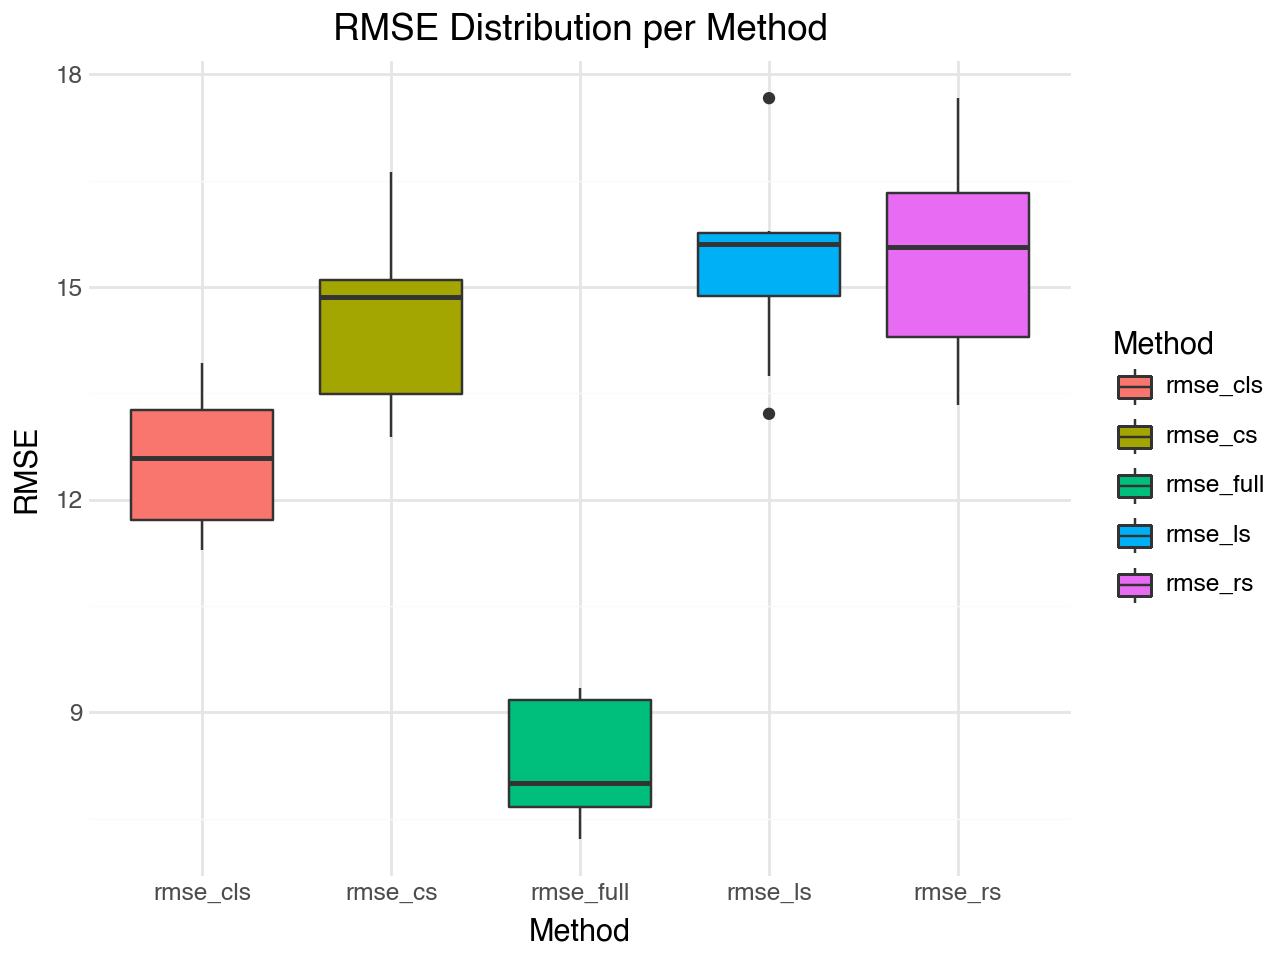

In [246]:
#==============================================================================================
# Simulation Study 1: p = 1.000, n = 900, reps = 10, k = 50, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 50

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)

In [247]:
#### LS Investigation
beta_train = pd.read_csv(f"{base}/{folder}/rep1/beta.csv")
#print(beta_train)
#beta = beta_train[0]
beta = beta_train.to_numpy().reshape(-1)
ls = scores['LS'][0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(ls)[-c:]
#print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
#print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den {len(true_nonzero)} Beta-Spalten sind {len(hits)} korrekt identifiziert")

Von den 200 Beta-Spalten sind 43 korrekt identifiziert


In [248]:
#### CLS Investigation
cls = scores['CLS'][0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cls))[-c:]
#print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
#print(beta[top_c_indices])

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den {len(true_nonzero)} Beta-Spalten sind {len(hits)} korrekt identifiziert")

tp = top_c_indices
print("Sum |beta| der gefundenen:")
print(np.sum(np.abs(beta[tp])))
print("Sum |beta|:")
print(np.sum(np.abs(beta)))

print("Max |beta| gefunden:")
print(np.max(np.abs(beta[tp])))
print("Max |beta|:")
print(np.max(np.abs(beta)))

Von den 200 Beta-Spalten sind 98 korrekt identifiziert
Sum |beta| der gefundenen:
100.94782486
Sum |beta|:
147.39213916673
Max |beta| gefunden:
2.6167068
Max |beta|:
2.6167068


In [249]:
#### CS Investigation
cs = scores['CS'][0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cs))[-c:]
#print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
#print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den {len(true_nonzero)} Beta-Spalten sind {len(hits)} korrekt identifiziert")

Von den 200 Beta-Spalten sind 80 korrekt identifiziert


In [250]:
#### RS Investigation
rs = scores['RS'][0]    
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(rs)[-c:]
#print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
#print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den {len(true_nonzero)} Beta-Spalten sind {len(hits)} korrekt identifiziert")

Von den 200 Beta-Spalten sind 36 korrekt identifiziert


c =  461.0
r =  2828.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


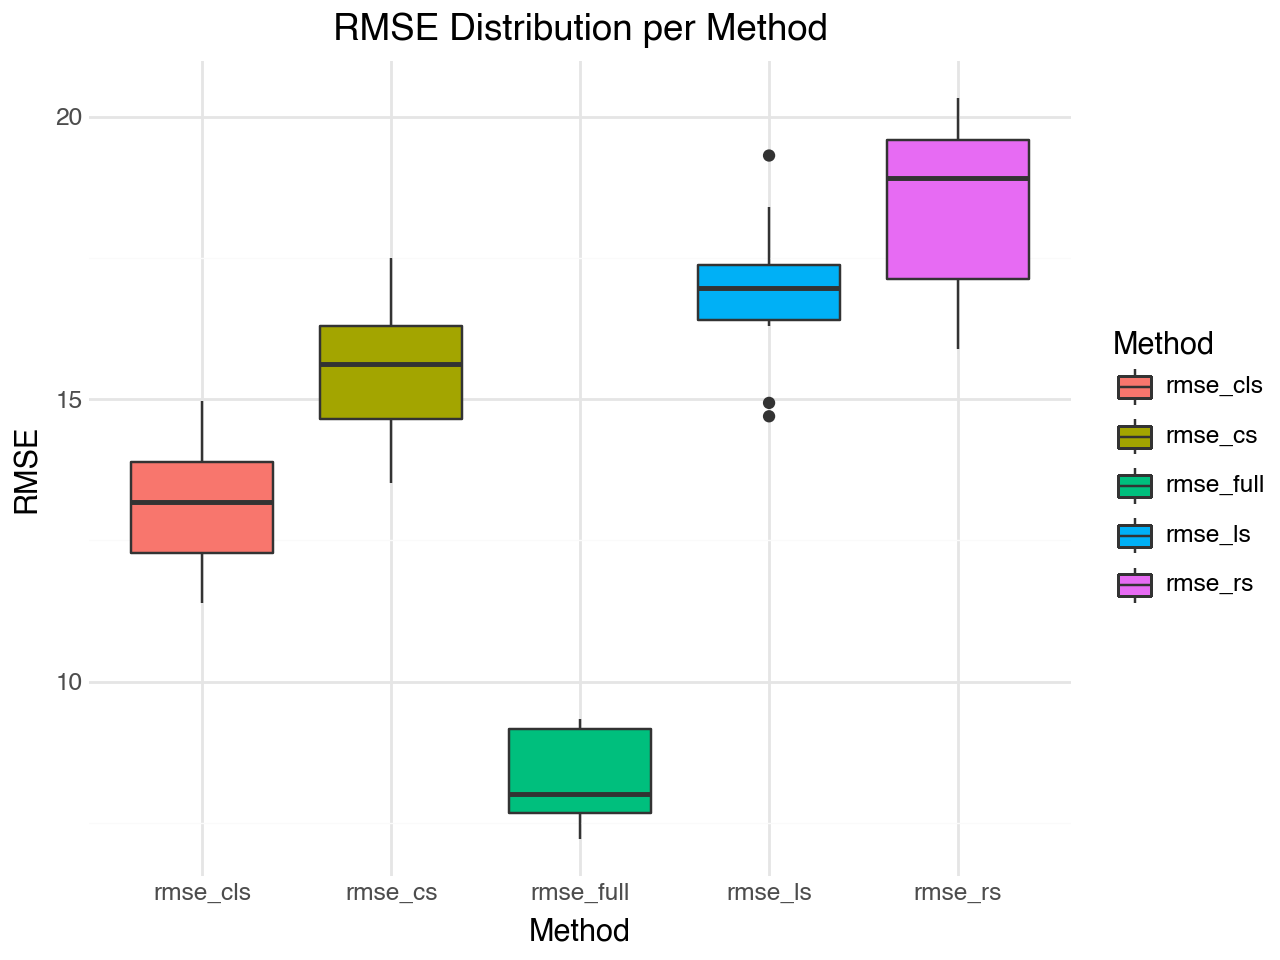

In [251]:
#==============================================================================================
# Simulation Study 2: p = 1.000, n = 900, reps = 10, k = 100, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 100

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)

c =  752.0
r =  4981.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


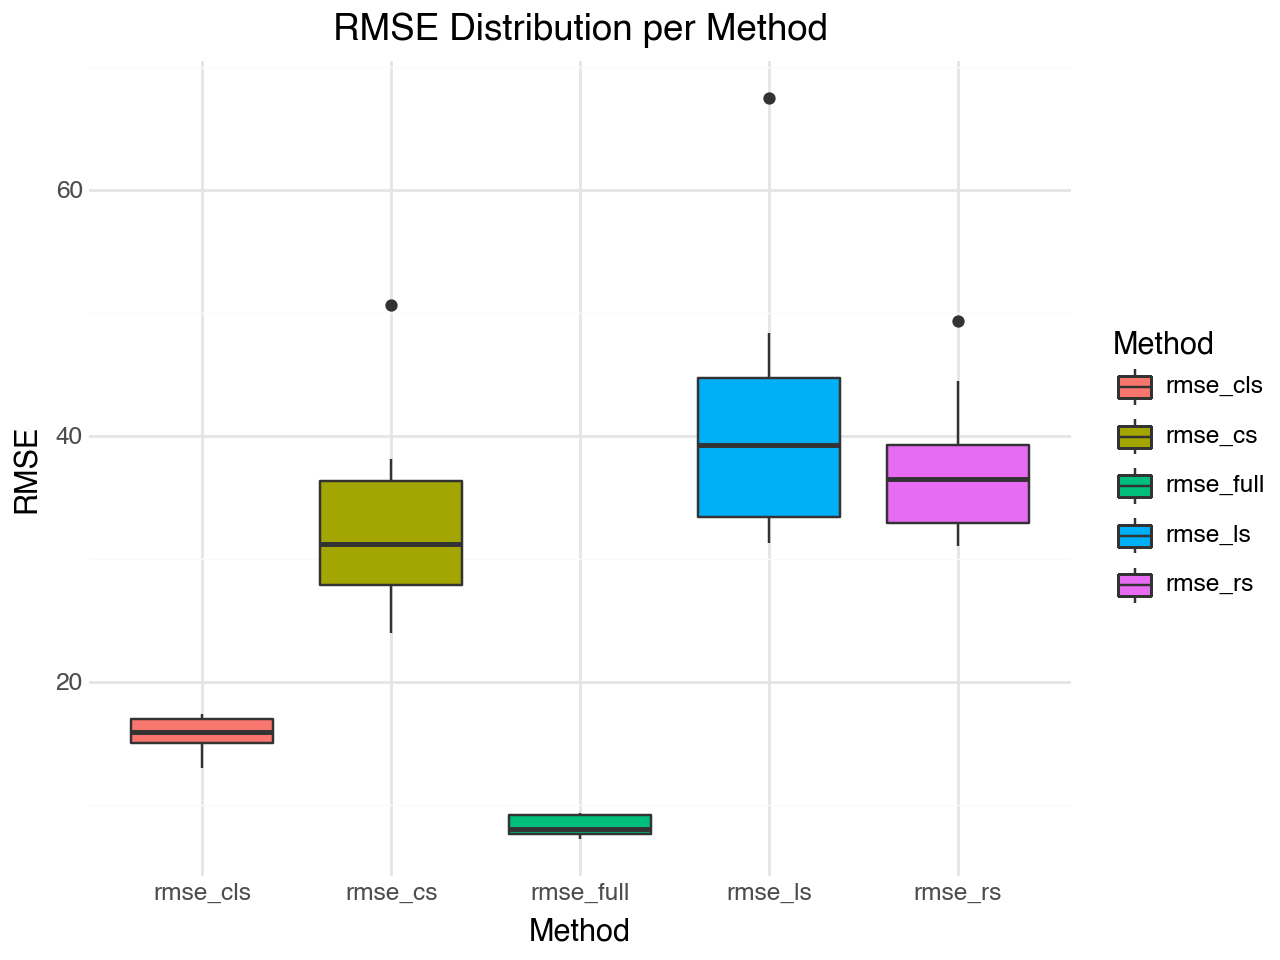

In [252]:
#==============================================================================================
# Simulation Study 3: p = 1.000, n = 900, reps = 10, k = 150, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 150

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)

c =  1060.0
r =  7384.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


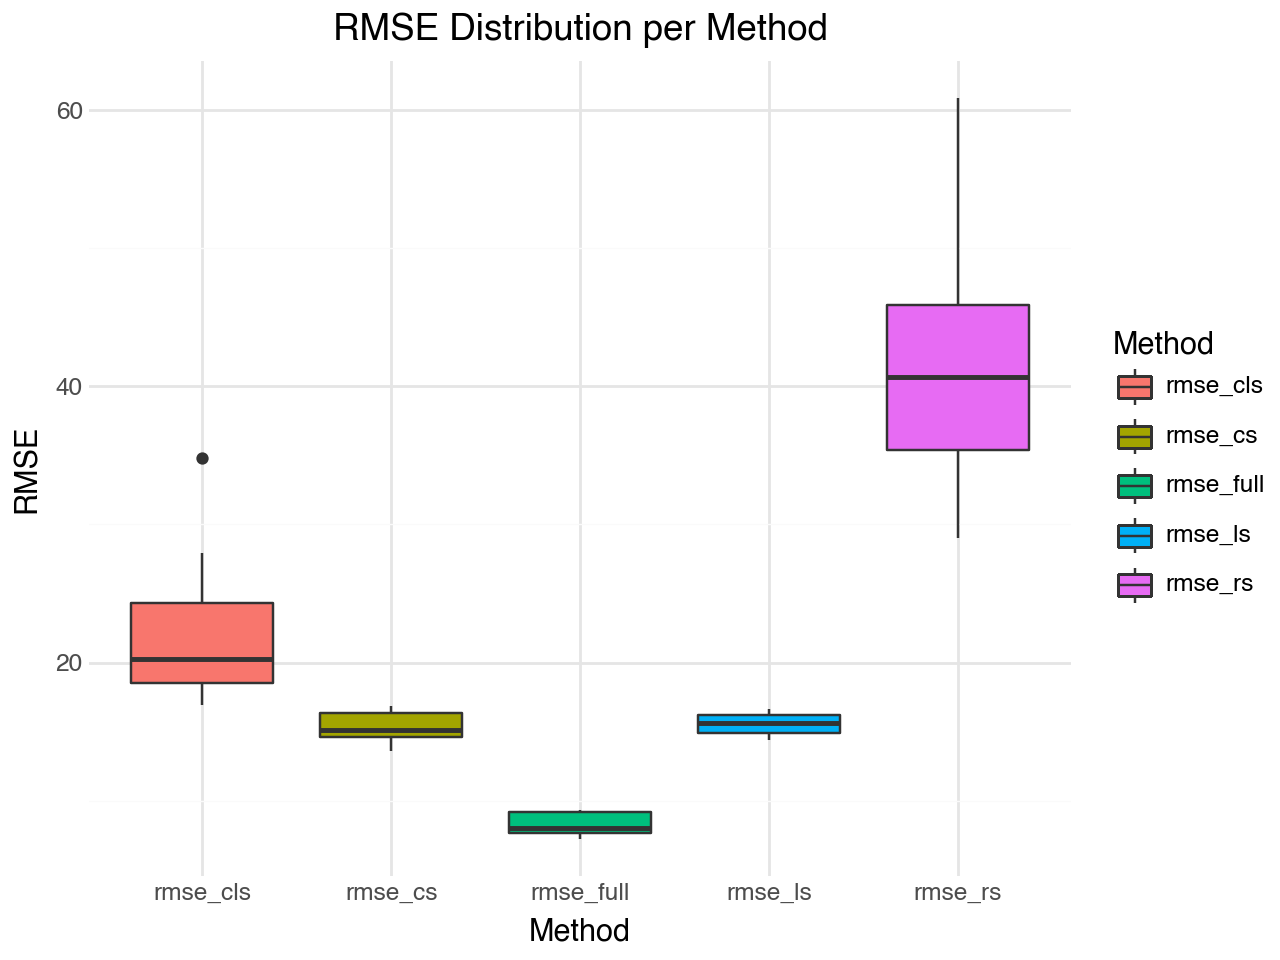

In [253]:
#==============================================================================================
# Simulation Study 4: p = 1.000, n = 900, reps = 10, k = 200, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 200

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)

c =  1712.0
r =  12747.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


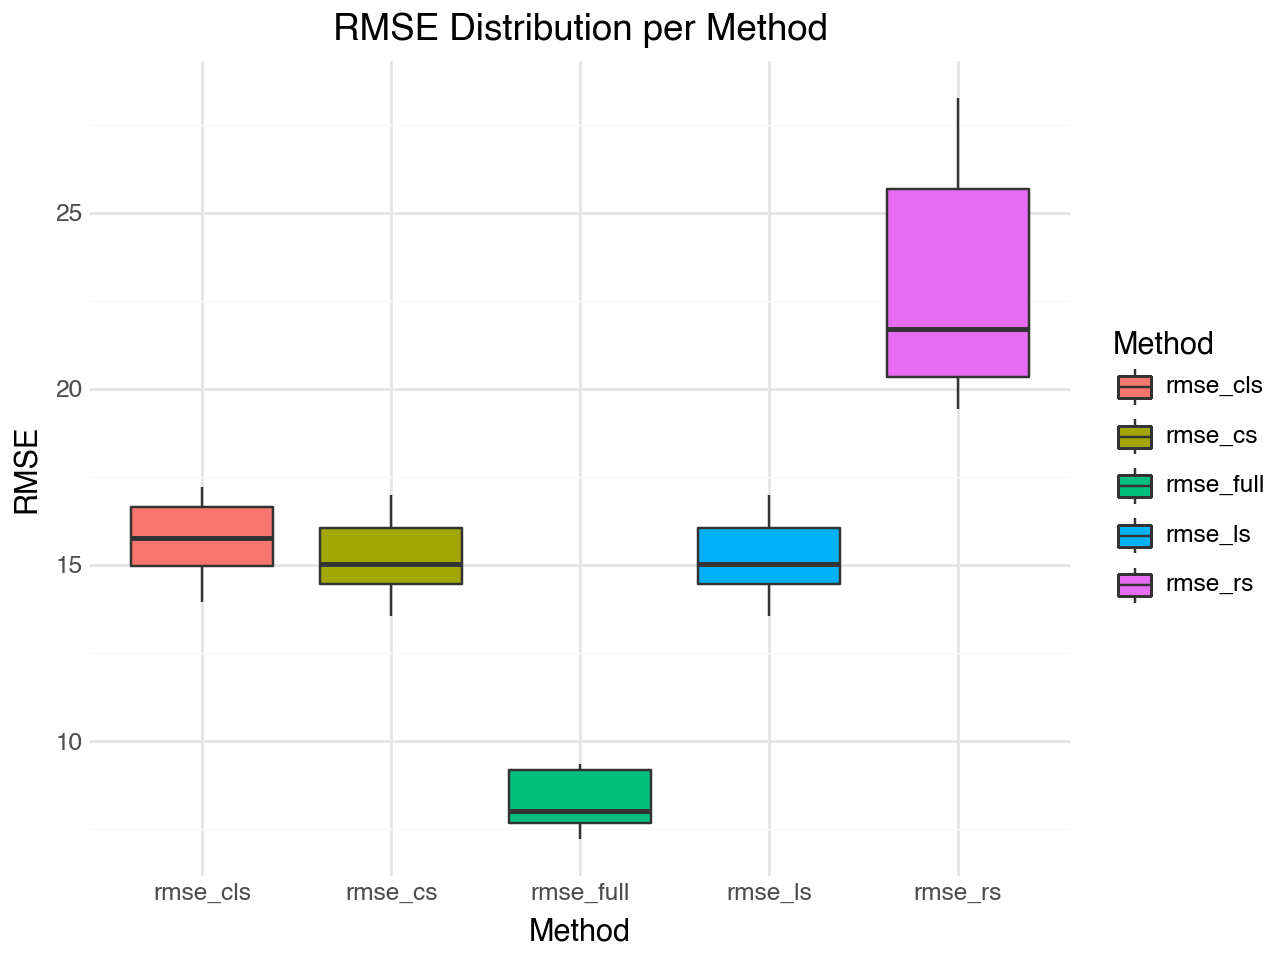

In [254]:
#==============================================================================================
# Simulation Study 5: p = 1.000, n = 900, reps = 10, k = 300, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 300

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)

c =  4586.0
r =  38664.0
Reading in the simulation data...
Setting the seed...
Performing data reduction...
Visualizing score distributions...
Building linear models...
Building Full Model / Benchmark...
Plotting RMSE...


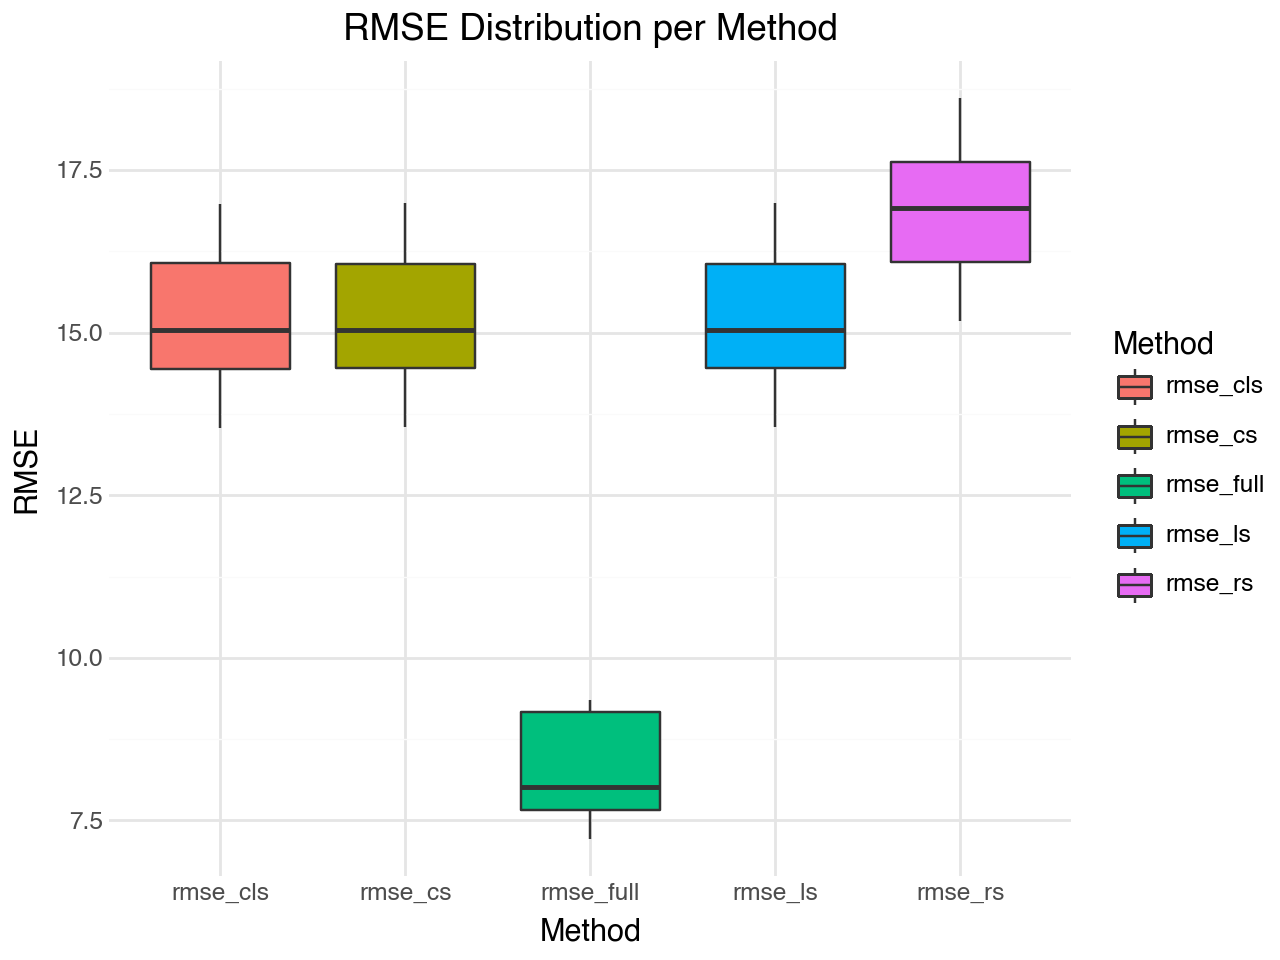

In [256]:
#==============================================================================================
# Simulation Study 6: p = 1.000, n = 900, reps = 10, k = 700, seed = 1
#==============================================================================================

# set the folder:
folder = "p1000_n900"

# set the seed:
seed = 1

# set the rank parameter k:
k = 700

# approximation of reduced dimensions:
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

# perform the study:
scores, C, R, rmse = simulation_study(k, seed, folder, 10)